# ⚡ Energy Forecast Hub - Exploratory Data Analysis (EDA)

This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the **Energy Forecast Hub** dataset. The dataset contains daily-aggregated household electric power consumption data along with engineered temporal features.

## 📋 Objectives
- Load and inspect the train (`df_train.csv`) and test (`df_test.csv`) datasets.
- Profile distributions, statistics, and missing values.
- Analyze temporal patterns, seasonality, and consumption trends (yearly, monthly, weekly, and daily).
- Explore relationship of categorical features (`day_in_week`, `quarter`, `month`) with `power_consumption`.
- Analyze correlations between numerical features to prepare for model building.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetics for premium visuals
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'sans-serif'
})

# Color palette definition
PRIMARY_COLOR = '#1f77b4'
SECONDARY_COLOR = '#ff7f0e'
ACCENT_COLOR = '#2ca02c'

## 💾 1. Data Loading & Initial Inspection
We load the preprocessed train and test data generated by `import_dataset.py`.

In [2]:
# Paths to datasets
base_dir = os.getcwd()
data_dir = os.path.join(base_dir, "data")
train_path = os.path.join(data_dir, "df_train.csv")
test_path = os.path.join(data_dir, "df_test.csv")

print(f"Loading train dataset from: {train_path}")
print(f"Loading test dataset from: {test_path}")

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# Convert date column to datetime object for proper time series analysis
df_train['date'] = pd.to_datetime(df_train['date'])
df_test['date'] = pd.to_datetime(df_test['date'])

# Apply feature engineering pipeline to calculate rolling average feature
from src.preprocessing import preprocess_data
df_train = preprocess_data(df_train)
df_test = preprocess_data(df_test)

print("\n--- Train Shape ---")
print(df_train.shape)
print("\n--- Test Shape ---")
print(df_test.shape)

Loading train dataset from: c:\Users\jconza\Downloads\energy-forecast-hub\data\df_train.csv
Loading test dataset from: c:\Users\jconza\Downloads\energy-forecast-hub\data\df_test.csv

--- Train Shape ---
(1202, 9)

--- Test Shape ---
(240, 9)


In [3]:
# Displaying first few rows of train set
df_train.head()

,date,power_consumption,year,semester,quarter,day_in_week,week_in_year,day_in_year,month
0,2006-12-16,1209.176,2006,2,4,Sat,50,350,12
1,2006-12-17,3390.460,2006,2,4,Sun,51,351,12
2,2006-12-18,2203.826,2006,2,4,Mon,51,352,12
3,2006-12-19,1666.194,2006,2,4,Tue,51,353,12
4,2006-12-20,2225.748,2006,2,4,Wed,51,354,12


## 🔍 2. Data Profiling & Quality Checks
Let's check the column types, summary statistics, and missing values.

In [4]:
print("--- Train Info ---")
df_train.info()
print("\n--- Missing Values in Train ---")
print(df_train.isnull().sum())
print("\n--- Missing Values in Test ---")
print(df_test.isnull().sum())

--- Train Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1202 entries, 0 to 1201
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               1202 non-null   datetime64[us]
 1   power_consumption  1202 non-null   float64       
 2   year               1202 non-null   int64         
 3   semester           1202 non-null   int64         
 4   quarter            1202 non-null   int64         
 5   day_in_week        1202 non-null   str           
 6   week_in_year       1202 non-null   int64         
 7   day_in_year        1202 non-null   int64         
 8   month              1202 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(6), str(1)
memory usage: 88.2 KB

--- Missing Values in Train ---
date                 0
power_consumption    0
year                 0
semester             0
quarter              0
day_in_week          0
week_in_year         0
day_in_ye

In [5]:
print("--- Descriptive Statistics for Train Set ---")
df_train.describe().T

--- Descriptive Statistics for Train Set ---


,count,mean,min,25%,50%,75%,max,std
date,1202,2008-08-07 12:00:00,2006-12-16 00:00:00,2007-10-12 06:00:00,2008-08-07 12:00:00,2009-06-03 18:00:00,2010-03-31 00:00:00,NaN
power_consumption,1202.0,1592.959253,0.0,1179.8415,1583.971,1952.9515,4773.386,632.497568
year,1202.0,2008.123128,2006.0,2007.0,2008.0,2009.0,2010.0,0.972467
semester,1202.0,1.472546,1.0,1.0,1.0,2.0,2.0,0.499453
quarter,1202.0,2.415141,1.0,1.0,2.0,3.0,4.0,1.153442
week_in_year,1202.0,25.455907,1.0,11.0,25.0,39.0,53.0,15.623968
day_in_year,1202.0,175.1797,1.0,76.0,171.0,271.0,366.0,109.371519
month,1202.0,6.25624,1.0,3.0,6.0,9.0,12.0,3.573317


## 📈 3. Target Variable Analysis (`power_consumption`)
We analyze the distribution of `power_consumption` in both the train and test sets to look for potential shifts.

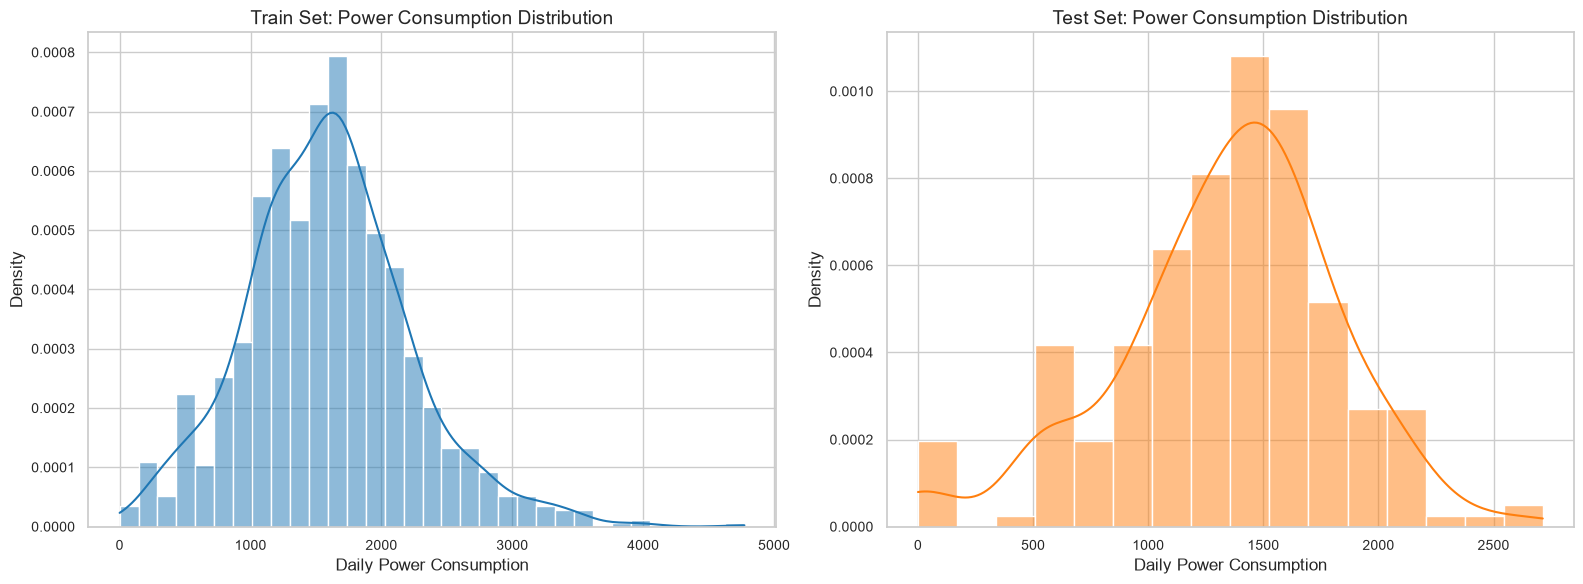

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram with KDE
sns.histplot(data=df_train, x="power_consumption", kde=True, color=PRIMARY_COLOR, ax=axes[0], stat="density")
axes[0].set_title("Train Set: Power Consumption Distribution")
axes[0].set_xlabel("Daily Power Consumption")

sns.histplot(data=df_test, x="power_consumption", kde=True, color=SECONDARY_COLOR, ax=axes[1], stat="density")
axes[1].set_title("Test Set: Power Consumption Distribution")
axes[1].set_xlabel("Daily Power Consumption")

plt.tight_layout()
plt.show()

In [7]:
# Comparison of stats
stats_df = pd.DataFrame({
    'Train': df_train['power_consumption'].describe(),
    'Test': df_test['power_consumption'].describe()
})
print("Power Consumption Comparison Statistics:")
stats_df

Power Consumption Comparison Statistics:


,Train,Test
count,1202.000000,240.00000
mean,1592.959253,1342.86600
std,632.497568,484.59382
min,0.000000,0.00000
25%,1179.841500,1102.65250
50%,1583.971000,1403.81800
75%,1952.951500,1649.95300
max,4773.386000,2713.88400


## 📅 4. Time Series Trend & Seasonality
Let's plot the complete time series of daily consumption to understand the long-term trends and seasonality.

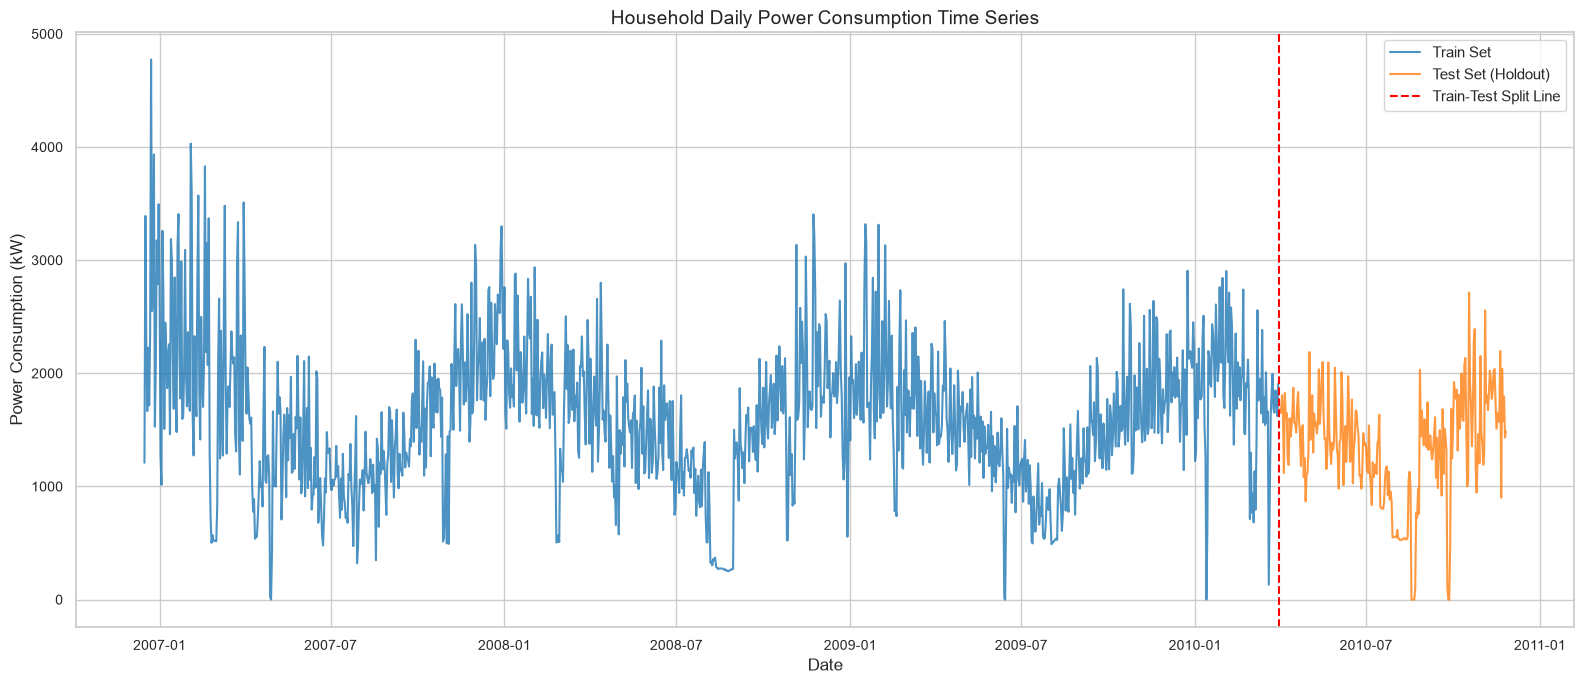

In [8]:
plt.figure(figsize=(16, 7))
plt.plot(df_train['date'], df_train['power_consumption'], label='Train Set', color=PRIMARY_COLOR, alpha=0.8)
plt.plot(df_test['date'], df_test['power_consumption'], label='Test Set (Holdout)', color=SECONDARY_COLOR, alpha=0.8)

plt.axvline(x=df_train['date'].max(), color='red', linestyle='--', label='Train-Test Split Line')
plt.title("Household Daily Power Consumption Time Series")
plt.xlabel("Date")
plt.ylabel("Power Consumption (kW)")
plt.legend()
plt.tight_layout()
plt.show()

### 🗓️ Monthly Resampling
Daily data is volatile. Let's aggregate it by month using resampling to see the macro-level seasonal cycle (winter vs summer consumption).

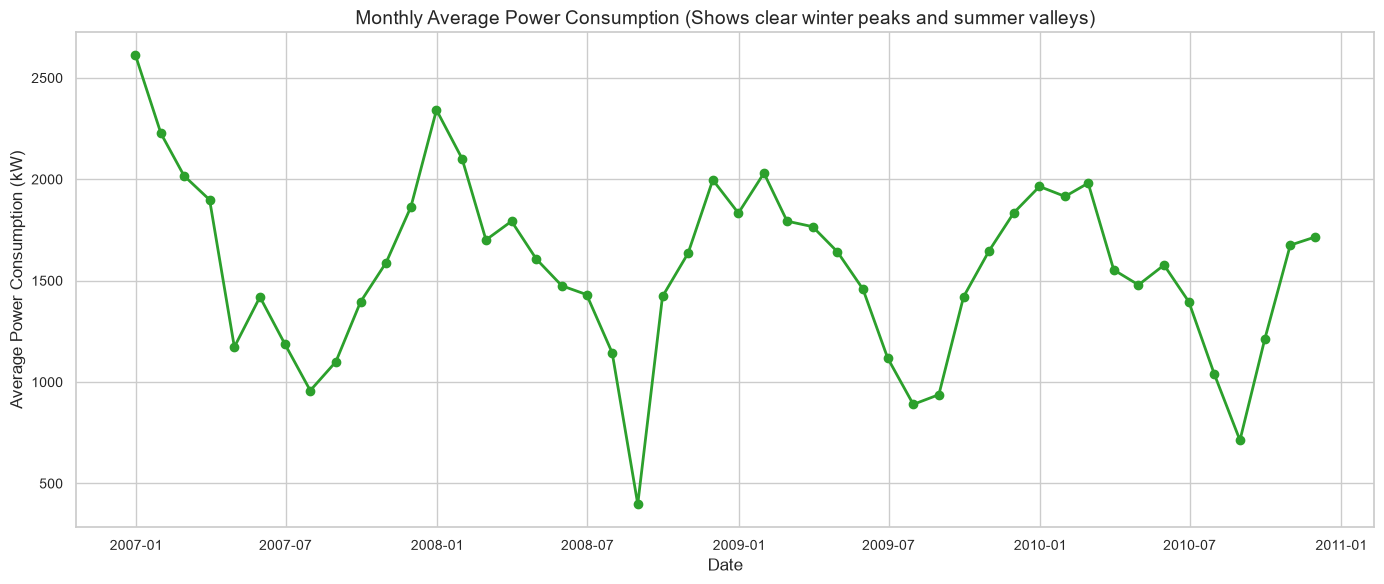

In [9]:
# Combine for complete trend plotting
df_full = pd.concat([df_train, df_test]).sort_values('date').set_index('date')

# Resample to monthly average
df_monthly = df_full['power_consumption'].resample('ME').mean().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(df_monthly['date'], df_monthly['power_consumption'], marker='o', color=ACCENT_COLOR, linewidth=2)
plt.title("Monthly Average Power Consumption (Shows clear winter peaks and summer valleys)")
plt.xlabel("Date")
plt.ylabel("Average Power Consumption (kW)")
plt.tight_layout()
plt.show()

## 📊 5. Seasonal Feature Exploratory Analysis
We examine how the engineered features (`day_in_week`, `quarter`, `month`) affect energy consumption.

C:\Users\jconza\AppData\Local\Temp\ipykernel_5960\3380989049.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x="day_in_week", y="power_consumption", order=day_order, ax=axes[0, 0], palette="Blues")
C:\Users\jconza\AppData\Local\Temp\ipykernel_5960\3380989049.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x="month", y="power_consumption", ax=axes[0, 1], palette="Oranges")
C:\Users\jconza\AppData\Local\Temp\ipykernel_5960\3380989049.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x="q

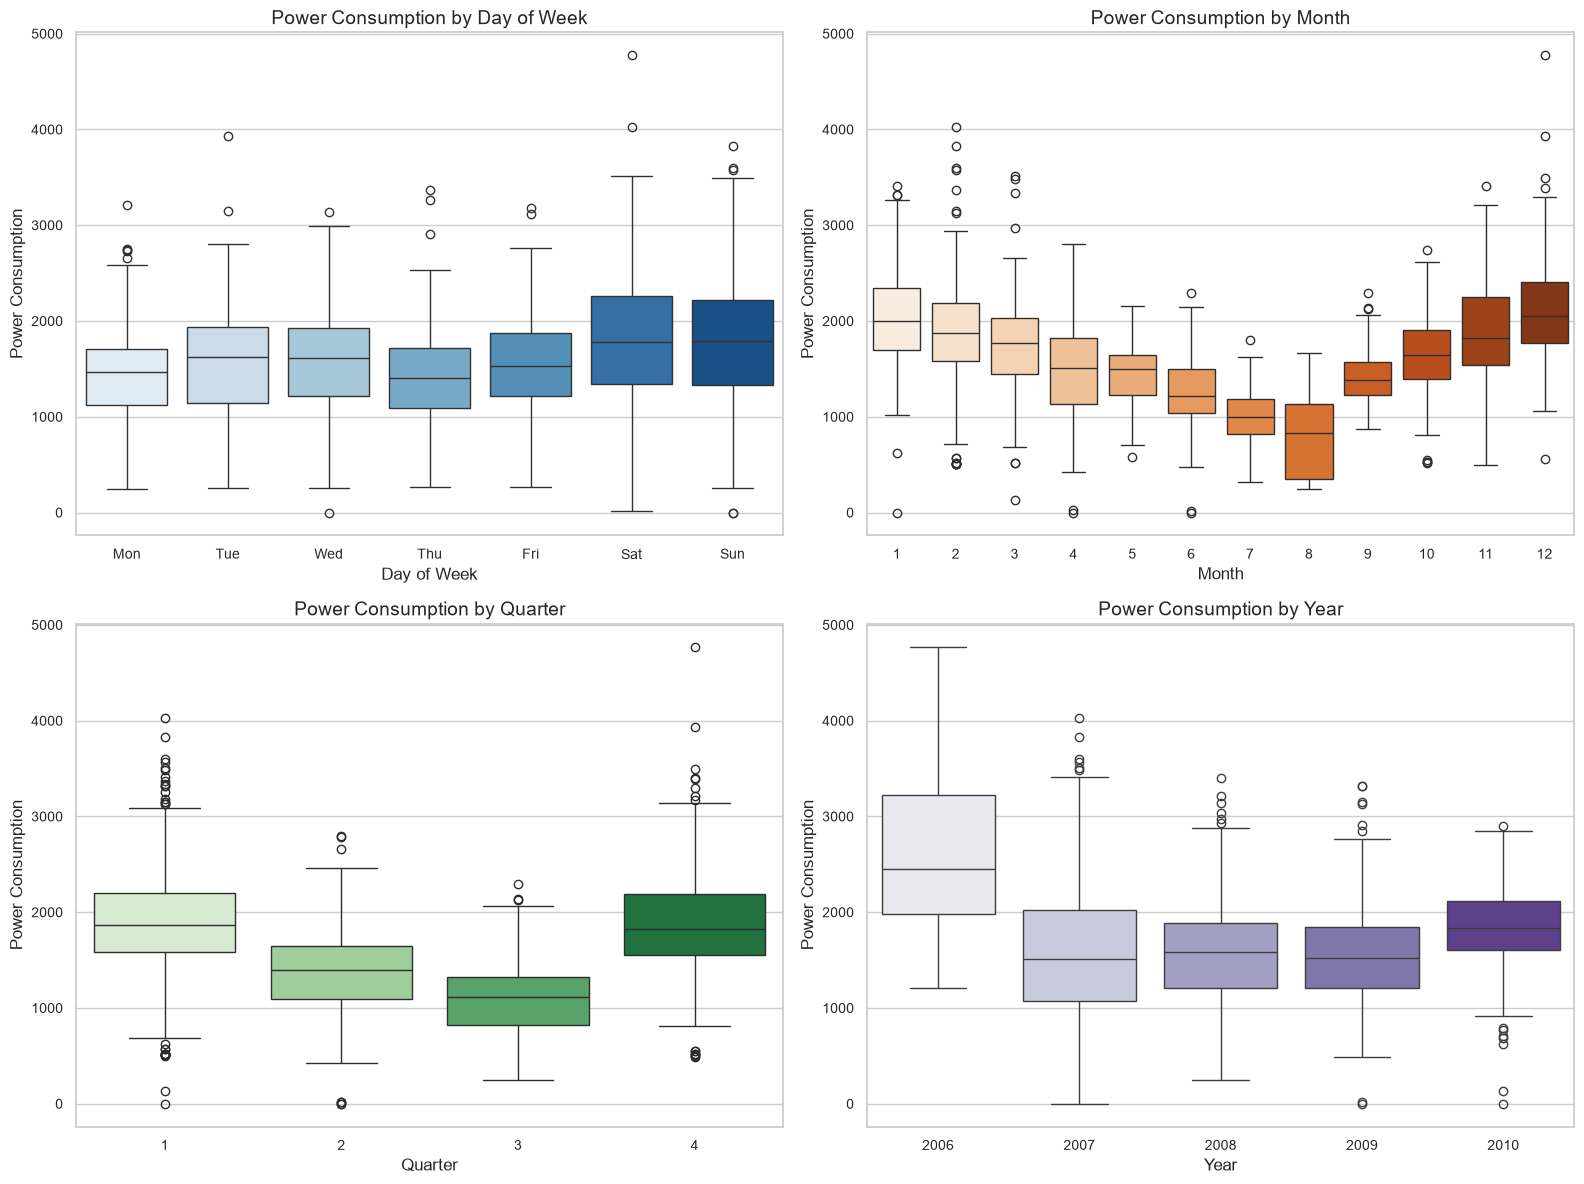

In [10]:
# Set day_in_week order
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Day of Week Boxplot
sns.boxplot(data=df_train, x="day_in_week", y="power_consumption", order=day_order, ax=axes[0, 0], palette="Blues")
axes[0, 0].set_title("Power Consumption by Day of Week")
axes[0, 0].set_xlabel("Day of Week")
axes[0, 0].set_ylabel("Power Consumption")

# 2. Month Boxplot
sns.boxplot(data=df_train, x="month", y="power_consumption", ax=axes[0, 1], palette="Oranges")
axes[0, 1].set_title("Power Consumption by Month")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Power Consumption")

# 3. Quarter Boxplot
sns.boxplot(data=df_train, x="quarter", y="power_consumption", ax=axes[1, 0], palette="Greens")
axes[1, 0].set_title("Power Consumption by Quarter")
axes[1, 0].set_xlabel("Quarter")
axes[1, 0].set_ylabel("Power Consumption")

# 4. Yearly Boxplot
sns.boxplot(data=df_train, x="year", y="power_consumption", ax=axes[1, 1], palette="Purples")
axes[1, 1].set_title("Power Consumption by Year")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Power Consumption")

plt.tight_layout()
plt.show()

## 📈 6. Autoregressive Feature Analysis (`power_rolling_mean_7d`)
We analyze the relationship between the 7-day rolling average feature (`power_rolling_mean_7d`) and the target variable `power_consumption`. This feature represents the historical average baseline of residential power usage.

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train, x='power_rolling_mean_7d', y='power_consumption', alpha=0.5, color=PRIMARY_COLOR)
sns.regplot(data=df_train, x='power_rolling_mean_7d', y='power_consumption', scatter=False, color=SECONDARY_COLOR)
plt.title("Relationship: Power Consumption vs 7-Day Rolling Mean")
plt.xlabel("7-Day Rolling Mean (kW)")
plt.ylabel("Current Power Consumption (kW)")
plt.tight_layout()
plt.show()


## 🔗 6. Feature Correlation Analysis
Let's see if there is any strong linear correlation between the temporal numerical features and our target variable.

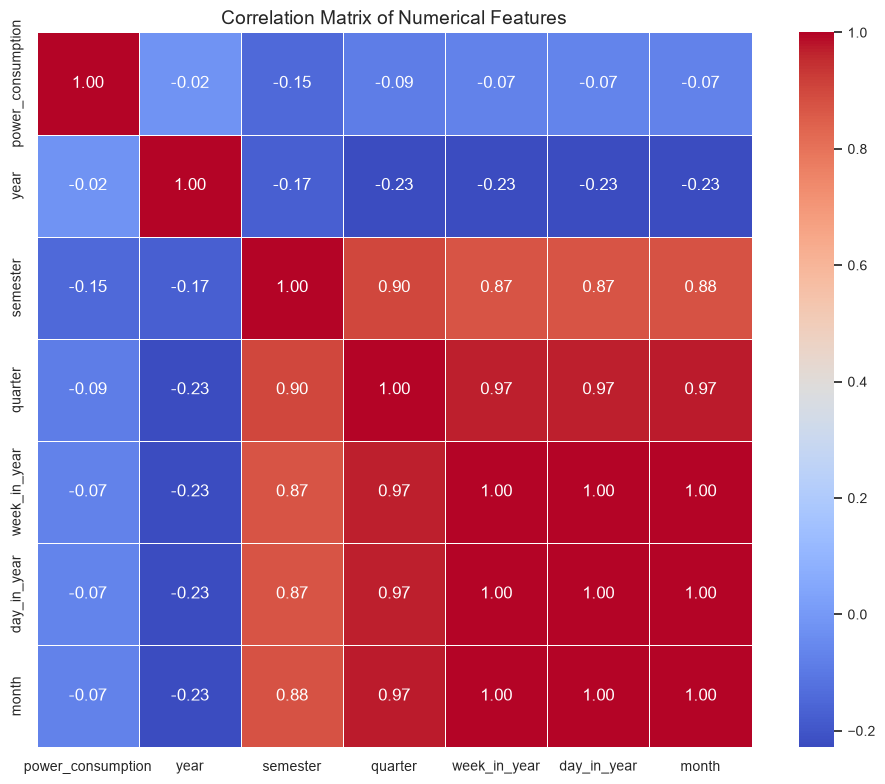

In [11]:
# Select numerical columns for correlation mapping
numerical_cols = ['power_consumption', 'year', 'semester', 'quarter', 'week_in_year', 'day_in_year', 'month', 'power_rolling_mean_7d']
corr_matrix = df_train[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, square=True)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()


## 💡 7. Key Findings & Insights
Based on the exploratory data analysis, we can summarize the following insights:
1. **Target Distribution**: Power consumption is right-skewed and ranges from ~0 to ~5000 kW, with a mean of around 1500–1600 kW.
2. **Seasonality**:
   - **Yearly Trend**: There is a clear annual cycle where power consumption peaks in the winter months (November, December, January) and decreases during the summer/shoulder seasons.
   - **Weekly Trend**: Energy consumption is noticeably higher on weekends (Saturday & Sunday) compared to weekdays, which is typical for household/residential profiles.
3. **Features Relevance**:
   - `month`, `quarter`, and `day_in_year` are likely to be highly informative for models due to the strong seasonality.
   - There is a negative correlation between `month` / `day_in_year` and power consumption overall, which reflects the spring/summer dips (but because it is non-linear/cyclic, tree-based models or sin-cos encoding might work better).
4. **Autoregressive Feature Influence**: The lag-1 7-day rolling average (`power_rolling_mean_7d`) has a strong positive correlation with current-day power consumption, representing the baseline energy behavior of the household. Tree-based regression models (like Random Forest) utilize this historical correlation heavily to make consistent, low-error forecasts.
